In [5]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [10]:
class KalmanFilterLSTM:
    def __init__(self, model_path, sequence_length, input_features, p_loss=0.1):
        self.model = tf.keras.models.load_model(model_path)
        self.sequence_length = sequence_length
        self.input_features = input_features
        self.p_loss = p_loss  # Probability of GPS loss
        
        # Kalman filter parameters
        self.A = np.eye(6)  # State transition matrix for position, velocity, and acceleration
        self.H = np.eye(2, 6)  # Observation matrix (we only observe position: lat, lng)
        self.Q = np.eye(6) * 0.001  # Process noise covariance
        self.R = np.eye(2) * 0.01  # Measurement noise covariance (adjustable)
        self.I = np.eye(6)  # Identity matrix
        self.P = np.eye(6)  # Initial covariance matrix
        self.state = None  # Initial state (to be initialized dynamically)

    def predict(self, acc_lat, acc_lng, delta_time=1):
        """
        Kalman Filter Prediction Step: Updates the state with sensor data (accelerometer).
        """
        # Update velocity using acceleration
        self.state[2, 0] += acc_lat * delta_time  # Update velocity in lat direction
        self.state[3, 0] += acc_lng * delta_time  # Update velocity in lng direction

        # Update position using velocity
        self.state[0, 0] += self.state[2, 0] * delta_time  # Update latitude
        self.state[1, 0] += self.state[3, 0] * delta_time  # Update longitude

        # Update covariance matrix
        self.P = self.A @ self.P @ self.A.T + self.Q  # Covariance prediction

    def update(self, measurement, use_lstm=False):
        """
        Kalman Filter Update Step: Corrects the prediction using either real GPS data or LSTM predictions.
        If use_lstm is True, LSTM predictions are treated as pseudo-measurements.
        """
        if use_lstm:
            # If using LSTM predictions, increase measurement noise to reflect lower confidence
            self.R = np.eye(2) * 0.05  # Adjust to a higher value to account for less reliable predictions
        else:
            # Regular GPS update with normal measurement noise
            self.R = np.eye(2) * 0.01

        # Measurement update step
        y = measurement - self.H @ self.state  # Measurement residual
        S = self.H @ self.P @ self.H.T + self.R  # Residual covariance
        K = self.P @ self.H.T @ np.linalg.inv(S)  # Kalman gain
        self.state = self.state + K @ y  # Updated state
        self.P = (self.I - K @ self.H) @ self.P  # Updated covariance matrix

    def calculate_routes(self, file_path):
        """
        Main function to calculate the real and predicted routes using the Kalman filter and LSTM.
        Randomly simulates GPS signal loss based on the probability p_loss.
        """
        data = pd.read_csv(file_path, delimiter=";")
        
        # Get the first point from 'Lat' and 'Lng'
        lng_real = [data.iloc[0]['Lng']]
        lat_real = [data.iloc[0]['Lat']]

        # Initialize predicted route with first known GPS position
        lng_pred = [data.iloc[0]['Lng']]
        lat_pred = [data.iloc[0]['Lat']]

        # Extract input data for LSTM predictions and sensor data
        input_data = data[self.input_features].values

        # Initialize Kalman filter state with the first GPS position (lat, lng, velocity_lat, velocity_lng, acc_lat, acc_lng)
        self.state = np.array([[lat_pred[0]], [lng_pred[0]], [0], [0], [0], [0]])  # Start with 0 velocity and 0 acceleration

        for i in range(1, len(data)):
            # Get acceleration data from sensors
            acc_lat = data.iloc[i]['Acc_X']  # Replace with actual mapping of lat direction acceleration
            acc_lng = data.iloc[i]['Acc_Y']  # Replace with actual mapping of lng direction acceleration

            # Prepare input sequence for LSTM prediction
            if i >= self.sequence_length:
                X_test = input_data[i - self.sequence_length:i].reshape(1, self.sequence_length, len(self.input_features))
                delta_lng_pred, delta_lat_pred = self.model.predict(X_test, verbose=0)[0] / 1000  # Verbose set to 0 to suppress output
                print("Predicted delta lat: {}, Predicted delta lng: {}".format(delta_lat_pred, delta_lng_pred))
                print("Real lat: {}, Real lng: {}".format(data.iloc[i]['delta_Lat'], data.iloc[i]['delta_Lng']))
                # Predict the next state using Kalman filter
                self.predict(acc_lat, acc_lng)  # Include sensor data in the prediction step

                # Simulate GPS loss using np.random.rand()
                if np.random.rand() > self.p_loss:
                    # Apply Kalman filter correction with real GPS data (if available)
                    measurement = np.array([data.iloc[i]['Lat'], data.iloc[i]['Lng']]).reshape(-1, 1)
                    self.update(measurement)
                else:
                    # Apply Kalman filter correction with LSTM predictions as pseudo-measurements
                    measurement = np.array([lat_pred[-1] + delta_lat_pred, lng_pred[-1] + delta_lng_pred]).reshape(-1, 1)
                    self.update(measurement, use_lstm=True)
                
                # Update the absolute position for prediction
                lng_pred.append(self.state[1, 0])
                lat_pred.append(self.state[0, 0])
            else:
                # Ensure we don’t index out of range (avoid IndexError)
                if i < len(lng_real) and i < len(lat_real):
                    # Use the real data for the first few rows
                    lng_pred.append(lng_real[i])
                    lat_pred.append(lat_real[i])

        return lat_real, lng_real, lat_pred, lng_pred
    
    def plot_routes(self, lat_real, lng_real, lat_pred, lng_pred, file_path):
        """
        Plots the real and predicted routes.
        """
        plt.figure(figsize=(10, 6))
        plt.plot(lng_real, lat_real, 'bo-', label='Real Route', linewidth=2)
        plt.plot(lng_pred, lat_pred, 'ro--', label='Predicted Route (Kalman)', linewidth=2)
        plt.title('Kalman Filtered Path vs Real GPS Data with Random GPS Loss Simulation for file {}'.format(file_path))
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.legend(loc='best')
        plt.grid(True)
        plt.show()


In [7]:
sequence_length = 20
input_features = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Tilt_X', 'Tilt_Y', 'Tilt_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'Head', 'Temp', 'Press', 'delta_Alt']

test_folder_path = 'data/test'
models_folder = 'models'

model_name = 'lstm_delta_gps_model.keras'

model_path = os.path.join(models_folder, model_name)

Predicted delta lat: 3.152636782033369e-05, Predicted delta lng: 1.820275792852044e-05
Real lat: -1.0999999993543952e-05, Real lng: 7.000000000090267e-06
Predicted delta lat: 3.587852552300319e-05, Predicted delta lng: 1.8727081624092534e-05
Real lat: -4.0000000041118255e-06, Real lng: 5.999999999062311e-06
Predicted delta lat: 4.157453076913953e-05, Predicted delta lng: 1.7598529666429386e-05
Real lat: -8.000000001118224e-06, Real lng: 4.999999999810711e-06
Predicted delta lat: 4.665657252189703e-05, Predicted delta lng: 1.55657617142424e-05
Real lat: 0.0, Real lng: 4.999999999810711e-06
Predicted delta lat: 5.025749487685971e-05, Predicted delta lng: 1.32000059238635e-05
Real lat: -8.000000001118224e-06, Real lng: 7.000000000090267e-06
Predicted delta lat: 5.17023763677571e-05, Predicted delta lng: 1.161475302069448e-05
Real lat: -6.999999996537554e-06, Real lng: -5.999999999062311e-06
Predicted delta lat: 5.1840328524122015e-05, Predicted delta lng: 1.138828883995302e-05
Real lat: 3

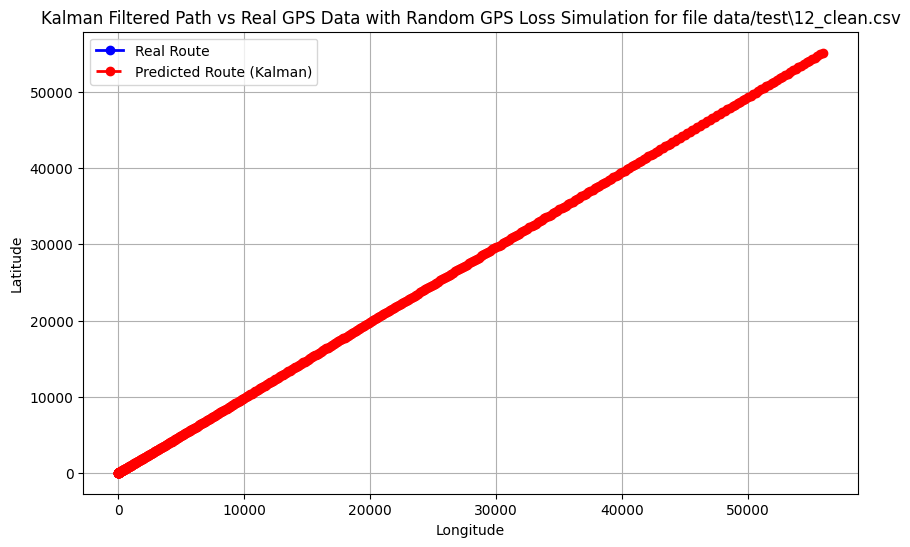

Predicted delta lat: 4.94444502692204e-05, Predicted delta lng: -7.869843830121681e-05
Real lat: -9.8999999998739e-05, Real lng: 3.300000000017178e-05
Predicted delta lat: 6.990563269937411e-05, Predicted delta lng: -8.614970283815637e-05
Real lat: -0.0001000000000033, Real lng: 3.0999999999892225e-05
Predicted delta lat: 7.63846401241608e-05, Predicted delta lng: -9.086052159545943e-05
Real lat: -0.0001030000000028, Real lng: 3.300000000017178e-05
Predicted delta lat: 7.064278179313987e-05, Predicted delta lng: -9.147530363406986e-05
Real lat: -0.0001029999999957, Real lng: 2.700000000110947e-05
Predicted delta lat: 7.288639608304948e-05, Predicted delta lng: -8.655448618810624e-05
Real lat: -0.0001790000000028, Real lng: 6.199999999978445e-05
Predicted delta lat: 9.564179345034063e-05, Predicted delta lng: -7.016590825514868e-05
Real lat: -7.999999999697138e-05, Real lng: 5.799999999922534e-05
Predicted delta lat: 0.0001247124164365232, Predicted delta lng: -5.104963565827347e-05
Rea

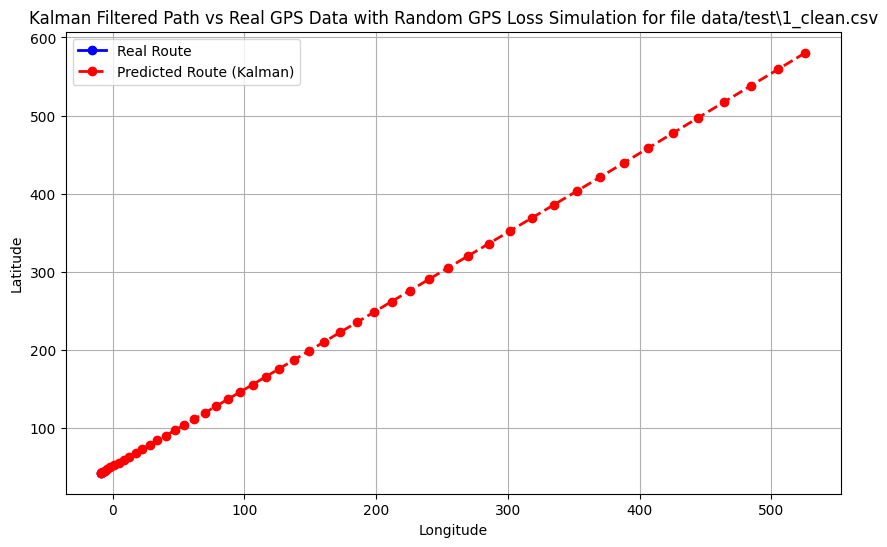

Predicted delta lat: 0.000179035821929574, Predicted delta lng: -2.7314376893627923e-06
Real lat: 2.2999999998774e-05, Real lng: 0.0001270000000008
Predicted delta lat: 0.0001877723989309743, Predicted delta lng: 1.6793510440038517e-05
Real lat: 1.9000000001767603e-05, Real lng: 0.0001129999999989
Predicted delta lat: 0.00015850829367991537, Predicted delta lng: 5.6504974054405466e-05
Real lat: 3.399999999942338e-05, Real lng: 9.499999999995624e-05
Predicted delta lat: 0.0001415814331267029, Predicted delta lng: 9.091648098547012e-05
Real lat: 7.599999999996498e-05, Real lng: 8.900000000089392e-05
Predicted delta lat: 0.00014525653386954218, Predicted delta lng: 0.00010530252620810643
Real lat: 0.0001760000000032, Real lng: 0.0001599999999992
Predicted delta lat: 0.00014280879986472428, Predicted delta lng: 0.00010992743773385882
Real lat: 8.399999999397778e-05, Real lng: 9.499999999995624e-05
Predicted delta lat: 0.00014056751388125122, Predicted delta lng: 0.0001082697999663651
Real 

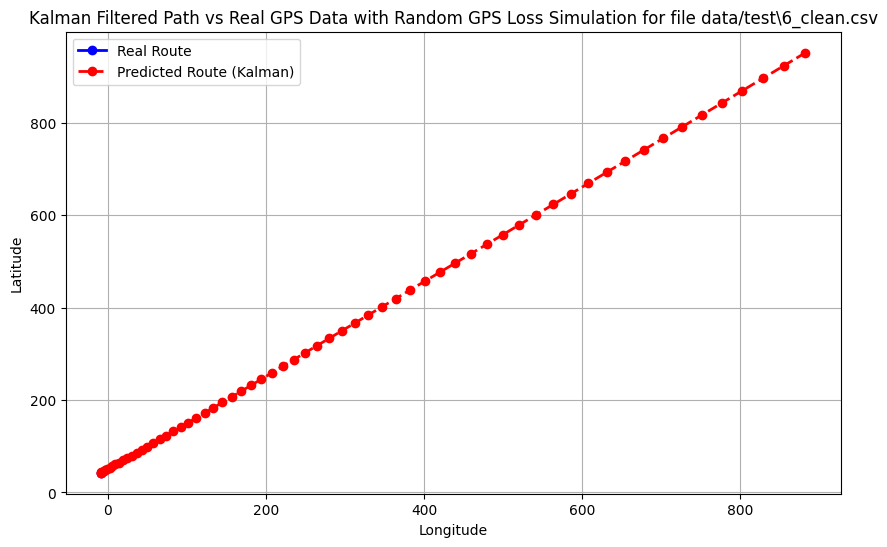

Predicted delta lat: 7.313907190109603e-06, Predicted delta lng: 2.4683749870746396e-05
Real lat: 2.599999999830516e-05, Real lng: -0.0001130000000006
Predicted delta lat: -0.0001264319143956527, Predicted delta lng: -5.945974862697767e-06
Real lat: -2.9999999995311555e-06, Real lng: -5.9999999999504894e-05
Predicted delta lat: -3.1693867640569806e-05, Predicted delta lng: -2.1472473235917278e-05
Real lat: 1.9000000001767603e-05, Real lng: -6.30000000008124e-05
Predicted delta lat: 6.638197373831645e-05, Predicted delta lng: 3.9804353946237825e-06
Real lat: 1.4999999997655776e-05, Real lng: -5.299999999941463e-05
Predicted delta lat: -2.61705517914379e-05, Predicted delta lng: 4.043503213324584e-05
Real lat: 2.7000000002885827e-05, Real lng: -5.400000000044258e-05
Predicted delta lat: 4.656352393794805e-05, Predicted delta lng: 2.9373182769631967e-05
Real lat: 4.899999999707916e-05, Real lng: -5.599999999894578e-05
Predicted delta lat: 0.00014136251411400735, Predicted delta lng: 2.261

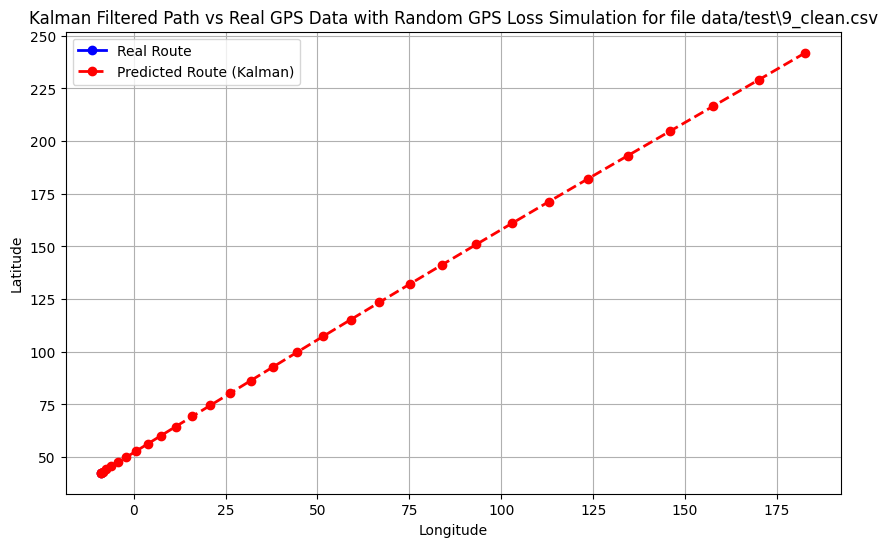

In [11]:
p_loss = 1

for file in os.listdir(test_folder_path):
    file_path = os.path.join(test_folder_path, file)
    # Calculate routes using the Kalman filter and LSTM
    kf_lstm = KalmanFilterLSTM(model_path, sequence_length, input_features, p_loss)
    lat_real, lng_real, lat_pred, lng_pred = kf_lstm.calculate_routes(file_path)
    # Plot the results
    kf_lstm.plot_routes(lat_real, lng_real, lat_pred, lng_pred, file_path)